# Contrast limits with Ruffio method

This tutorial covers Ruffio-style contrast-limit estimation on interferometry data, including likelihood evaluation on a spatial grid, local uncertainty estimation via Laplace approximation, and conversion to practical upper-limit maps and radial summaries. It highlights finite-value diagnostics and visualization choices in both flux-ratio and Δmag units so sensitivity structure is interpretable for scientific comparison.

In [ ]:
import jax.numpy as jnp
import numpy as onp
import jax.scipy as jsp
import matplotlib.pyplot as plt
import pyoifits as oifits

from drpangloss.models import OIData, BinaryModelCartesian
from drpangloss.grid_fit import (
    likelihood_grid,
    optimized_contrast_grid,
    laplace_contrast_uncertainty_grid,
    ruffio_upperlimit,
    absil_limits,
)
from drpangloss.plotting import (
    plot_contrast_limit_map,
    radial_limit_summary,
    plot_radial_limit_summary,
)

In [ ]:
rng = onp.random.default_rng(7)

fname = "NuHor_F480M.oifits"
ddir = "../data/"
data = oifits.open(ddir + fname)
try:
    data.verify("silentfix")
except AttributeError:
    pass

oidata = OIData(data)

# Pure-noise injection amplitude (1.0 uses nominal OIData uncertainties).
noise_amp = 1.0

sim_data = {
    "u": oidata.u,
    "v": oidata.v,
    "wavel": oidata.wavel,
    "vis": jnp.ones_like(oidata.vis)
    + noise_amp * jnp.array(rng.normal(size=oidata.vis.shape)) * oidata.d_vis,
    "d_vis": oidata.d_vis,
    "phi": noise_amp * jnp.array(rng.normal(size=oidata.phi.shape)) * oidata.d_phi,
    "d_phi": oidata.d_phi,
    "i_cps1": oidata.i_cps1,
    "i_cps2": oidata.i_cps2,
    "i_cps3": oidata.i_cps3,
    "v2_flag": oidata.v2_flag,
    "cp_flag": oidata.cp_flag,
}

oidata_sim = OIData(sim_data)

{"noise_amp": noise_amp, "vis_std": float(jnp.std(sim_data["vis"] - 1.0)), "phi_std": float(jnp.std(sim_data["phi"]))}

In [ ]:
samples = {
    "dra": jnp.linspace(-250.0, 250.0, 61),
    "ddec": jnp.linspace(-250.0, 250.0, 61),
    "flux": 10 ** jnp.linspace(-5.0, -1.5, 50),
}

ll_cube = likelihood_grid(oidata_sim, BinaryModelCartesian, samples)
opt_flux = optimized_contrast_grid(oidata_sim, BinaryModelCartesian, samples)
best_idx = jnp.argmax(ll_cube, axis=2)
sigma_flux = laplace_contrast_uncertainty_grid(
    best_idx, oidata_sim, BinaryModelCartesian, samples
)

# Ruffio method at 2σ equivalent percentile
perc = jnp.array([jsp.stats.norm.cdf(2.0)])
ruffio_flat = ruffio_upperlimit(opt_flux.flatten(), sigma_flux.flatten(), perc)
ruffio_map = ruffio_flat.reshape(*opt_flux.shape, perc.shape[0])[:, :, 0]

# Absil method at 2σ
absil_map = absil_limits(samples, oidata_sim, BinaryModelCartesian, sigma=2.0)

{
    "opt_flux_finite_frac": float(jnp.mean(jnp.isfinite(opt_flux))),
    "sigma_flux_finite_frac": float(jnp.mean(jnp.isfinite(sigma_flux))),
    "ruffio_finite_frac": float(jnp.mean(jnp.isfinite(ruffio_map))),
    "absil_finite_frac": float(jnp.mean(jnp.isfinite(absil_map))),
    "ruffio_median": float(jnp.nanmedian(ruffio_map)),
    "absil_median": float(jnp.nanmedian(absil_map)),
}

W0304 00:01:29.563588 2574370 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


{'opt_flux_finite_frac': 1.0,
 'sigma_flux_finite_frac': 0.9997313022613525,
 'limit_finite_frac': 0.9997313022613525,
 'limit_min': 0.000561241467949003,
 'limit_median': 0.0011003934778273106,
 'limit_max': 0.8645578026771545}

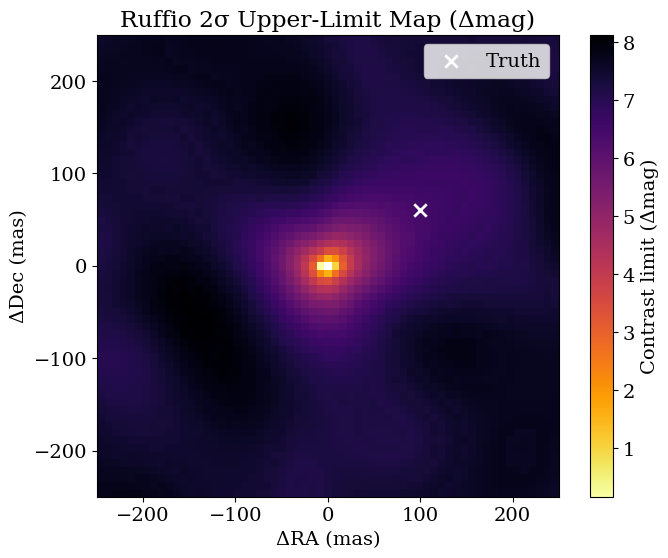

In [ ]:
# 2D contrast-limit maps (Δmag): Ruffio and Absil

dra_axis = onp.array(samples["dra"])
ddec_axis = onp.array(samples["ddec"])
ruffio_np = onp.array(ruffio_map)
absil_np = onp.array(absil_map)

plot_contrast_limit_map(
    ruffio_np,
    dra_axis,
    ddec_axis,
    truth=None,
    unit_mode="delta_mag",
    title="Ruffio 2σ Upper-Limit Map (Δmag)",
    cmap="inferno",
)
plt.show()

plot_contrast_limit_map(
    absil_np,
    dra_axis,
    ddec_axis,
    truth=None,
    unit_mode="delta_mag",
    title="Absil 2σ Limit Map (Δmag)",
    cmap="inferno",
)
plt.show()

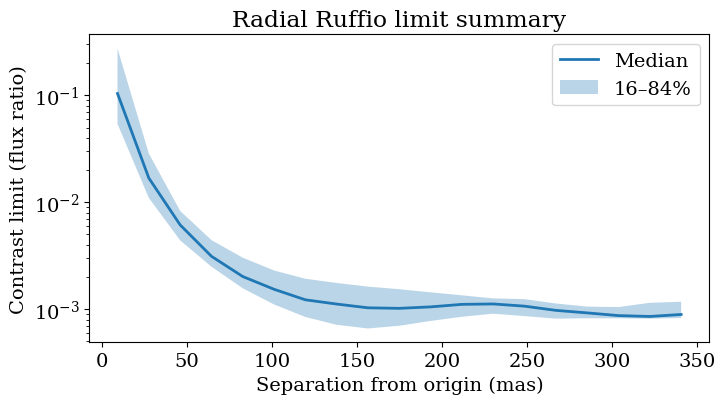

In [ ]:
# Radial summary: median and spread of limits vs separation (Ruffio and Absil)
ruffio_radial_summary = radial_limit_summary(
    ruffio_np,
    dra_axis,
    ddec_axis,
    center=(0.0, 0.0),
    r_max=350.0,
    n_bins=20,
)
plot_radial_limit_summary(
    ruffio_radial_summary,
    unit_mode="flux_ratio",
    title="Radial Ruffio limit summary",
)
plt.xlabel("Separation from origin (mas)")
plt.show()

absil_radial_summary = radial_limit_summary(
    absil_np,
    dra_axis,
    ddec_axis,
    center=(0.0, 0.0),
    r_max=350.0,
    n_bins=20,
)
plot_radial_limit_summary(
    absil_radial_summary,
    unit_mode="flux_ratio",
    title="Radial Absil limit summary",
)
plt.xlabel("Separation from origin (mas)")
plt.show()